In [1]:
import pandas as pd
import numpy as np
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV # MODIFICA: Importato GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# scaricare le risorse NLTK
# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')

# creiamo un set contenente le parole inutili (stop words) inglesi (come 'the', 'a' ...)
stop_words = set(stopwords.words('english'))
# creiamo un instanza lemmatizer (la usiamo dopo) per ridurre le parole nella loro forma base
lemmatizer = WordNetLemmatizer()

In [2]:
# Leggo il file CSV
try:
    rev = pd.read_csv("amazon_reviews_Musical_Instruments.csv", on_bad_lines='skip')
    # skippiamo le righe che potrebbero dare errore (anche se è molto difficile)
except FileNotFoundError:
    print("Errore: il file 'amazon_reviews_Musical_Instruments.csv' non è stato trovato.")
    exit()

# Utilizzo delle colonne 'title', 'text' e 'rating' come spiegato nella traccia
df = rev[['rating', 'title', 'text']].copy()
# per sicurezza rimuoviamo tutte le righe mancanti
df.dropna(subset=['title', 'text', 'rating'], inplace=True)

# Definiamo una lista per il 'sentiment' basata sulle valutazione degli utenti
conditions = [
    (df['rating'] <= 2), # 0: Negativo (rating 1-2)
    (df['rating'] == 3), # 1: Neutro (rating 3)
    (df['rating'] >= 4) # 2: Positivo (rating 4-5)
]
choices = [0, 1, 2] # 0=Negativo, 1=Neutro, 2=Positivo 

# andiamo a creare una nuova colonna sentiment usando 'select'
# 'select' assegna le 'choices' alle 'conditions'. lo fa come lo farebbe un if-elif
# se la condizione df['rating'] <= 2 è True allora assegnerà 0, in tutti gli altri casi non assegnerà MAI 0
# Il default 1 significa solo che se succede qualcosa di strano assegna di default 1 (ovvero sentiment neutro)
df['sentiment'] = np.select(conditions, choices, default=1)

In [ ]:
#  Questo calcola la frequenza/distribuzione di ogni categoria nella colonna 'sentiment'
class_counts = df['sentiment'].value_counts()
print("Distribuzione originale del sentiment:")
print(class_counts)

In [3]:
# Calcoliamo i pesi per ogni classe (inversamente proporzionali alla frequenza)
# Ciò significa che le classi meno frequenti avranno un peso maggiore, mentre le classi più frequenti avranno un peso minore.
# In questo modo tutto si bilancia
class_weights = 1 / class_counts
print("\nPesi calcolati per ogni classe:")
print(class_weights)

# Mappiamo i pesi di classe a ogni singola riga del dataframe. Ogni riga avrà un peso a seconda del suo sentiment
# Se una riga ha un sentimento "positivo" e i positivi sono molto comuni, quella riga avrà un peso basso. 
# Se ha un sentimento "negativo" e i negativi sono rari, quella riga avrà un peso alto.
row_weights = df['sentiment'].map(class_weights)

# Quando si usa df.sample() con il parametro weights, le righe vengono selezionate con una probabilità proporzionale al loro peso. 
# Alle classi meno rappresentate sono stati assegnati pesi maggiori, quindi avranno una probabilità più alta di essere scelte
df_sample = df.sample(n=10000, weights=row_weights, random_state=42)


print("\nDistribuzione del sentiment nel NUOVO campione pesato:")
# Vedrai che ora le classi sono molto più bilanciate!
print(df_sample['sentiment'].value_counts(normalize=True)) 
print(f"\nDimensioni del dataframe campione: {df_sample.shape}")

Distribuzione originale del sentiment:
sentiment
2    2423610
0     395708
1     197080
Name: count, dtype: int64

Pesi calcolati per ogni classe:
sentiment
2    4.126076e-07
0    2.527116e-06
1    5.074082e-06
Name: count, dtype: float64

Distribuzione del sentiment nel NUOVO campione pesato:
sentiment
0    0.3419
2    0.3331
1    0.3250
Name: proportion, dtype: float64

Dimensioni del dataframe campione: (10000, 4)


In [4]:
# processamento del Testo con NLP

# Funzione per pulire e preparare una singola stringa di testo
def preprocess_text(text):
    if pd.isnull(text):
        return ""               # ritorniamo una stringa vuota per evitare di far crushare il programma
    # in realtà non serve perché abbiamo già 
    text = str(text).lower()   # usiamo str così un numero non darà errore 
    text = text.translate(str.maketrans('', '', string.punctuation))   # rimuoviamo la punteggiatura
    tokens = nltk.word_tokenize(text)     # la stringa viene divisa in 'parole' o 'token' che sono pià facili da analizzare singolarmente
    tokens = [word for word in tokens if word not in stop_words]   # rimuoviamo word per word tutte le parole inutili
    tokens = [lemmatizer.lemmatize(word) for word in tokens]       # word per word le 'semplifichiamo' tutte
    return ' '.join(tokens)    # importante, riuniamo le parole 'semplificate e utili' in un unica stringa
    # così per coerenza in input abbiamo una stringa e in ouput abbiamo una stringa, non parole singole a casaccio
    
    
# Combiniamo 'title' e 'text' per un contenuto più ricco
df_sample['full_text'] = df_sample['title'] + ' ' + df_sample['text']

print("\nInizio del preprocessing del testo...")
# Applichiamo la funzione di preprocessing usando apply
df_sample['text_clean'] = df_sample['full_text'].apply(preprocess_text)
print("Preprocessing completato.")

# Prepariamo il DataFrame finale
df_final = df_sample[['sentiment', 'text_clean']].copy()
# resettiamo l'indice del dataframe, quando abbiamo tolto le stop words ptrebbe essersi sminchiato l'ordine (indice) degli elementi
df_final.reset_index(drop=True, inplace=True)

# vediamo com'è il nostro nuovo dataframe 
display(df_final.head())


Inizio del preprocessing del testo...
Preprocessing completato.


,sentiment,text_clean
0,1,acceptable hand slender long finger found fing...
1,0,sure hope fluke really disappointed 350 w vega...
2,0,buy could get work computer speaker customer s...
3,0,returned useable garbage distorts easily unles...
4,0,claim put standard guitar little hope keep mov...


In [5]:
# Suddivisione dei Dati in Training e Test Set

# Suddividiamo il dataset in modo globale
X = df_final['text_clean']       # features (dati con cui addestro il modello)
y = df_final['sentiment']        # i sentiment da predire (ovvero le risposte corrette)

# 25% dei dati al test set e 75% al train set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y   
)
# i valori all'interno di y devono essere bilanciati, quindi il numero di 0,1,2 (recensioni negative neutre e positve) deve essere uguale
# altrimenti alleno il mio modello su una certa disposizione di dati e poi
# lo testo su un test set che una diversa, rendendo l'allenamento difficile da verificare

# stampa
print(f"\nDimensioni del Training Set: {X_train.shape[0]}")
print(f"Dimensioni del Test Set: {X_test.shape[0]}")


# Bag-of-Words (BoW) e SVM

print("\n--- Addestramento e Valutazione Modello BoW + SVM ---")

# 1. Vettorizzazione con Bag-of-Words (invariata)
vectorizer = CountVectorizer(max_features=5000)   # 5000 parole più frequenti
X_train_bow = vectorizer.fit_transform(X_train)   # impara il vocabolario e ottieni i vettori
X_test_bow = vectorizer.transform(X_test)         # ottieni i vettori dal vocabolario imparato
# 
print(f"Forma della matrice BoW (Training): {X_train_bow.shape}")

# Setup di GridSearchCV per LinearSVC, definiamo la "griglia" di iperparametri da testare
param_grid_bow = {
    'C': [0.1, 1, 10, 100],  # Testa diversi valori per il parametro di regolarizzazione C
    'dual': [True, False] # Testa entrambe le opzioni per l'algoritmo di ottimizzazione
}

# Creiamo l'oggetto GridSearchCV
grid_search_bow = GridSearchCV(
    LinearSVC(random_state=42, max_iter=4000, class_weight='balanced'), # Il modello da ottimizzare
    param_grid_bow,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1 # Aggiunge output per vedere l'avanzamento
)

# Addestramento (la ricerca vera e propria degli iperparametri)
print("\nInizio della GridSearchCV per BoW + SVM...")
grid_search_bow.fit(X_train_bow, y_train)
print("GridSearchCV completata.")

# Ottenere il modello e i risultati migliori
print(f"Migliori iperparametri trovati per BoW: {grid_search_bow.best_params_}")
best_svm_bow = grid_search_bow.best_estimator_ # Questo è il modello SVM già addestrato con i parametri migliori

# Predizione e Valutazione con il modello ottimizzato
y_pred_bow = best_svm_bow.predict(X_test_bow)    # Prediciamo il test set di y
accuracy_bow = accuracy_score(y_test, y_pred_bow)
report_bow = classification_report(y_test, y_pred_bow, target_names=['Negativo', 'Neutro', 'Positivo'])

print(f"\nAccuratezza del modello OTTIMIZZATO BoW + SVM: {accuracy_bow:.4f}")
print("\nClassification Report (BoW ottimizzato):")
print(report_bow)


Dimensioni del Training Set: 7500
Dimensioni del Test Set: 2500

--- Addestramento e Valutazione Modello BoW + SVM ---
Forma della matrice BoW (Training): (7500, 5000)

Inizio della GridSearchCV per BoW + SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV completata.
Migliori iperparametri trovati per BoW: {'C': 0.1, 'dual': True}

Accuratezza del modello OTTIMIZZATO BoW + SVM: 0.6940

Classification Report (BoW ottimizzato):
              precision    recall  f1-score   support

    Negativo       0.70      0.72      0.71       855
      Neutro       0.61      0.53      0.57       812
    Positivo       0.76      0.83      0.79       833

    accuracy                           0.69      2500
   macro avg       0.69      0.69      0.69      2500
weighted avg       0.69      0.69      0.69      2500



In [6]:
# Transformer Embeddings e SVM

print("\n--- Addestramento e Valutazione Modello Transformer ---")

# Generazione degli Embeddings con un modello Transformer
# Usiamo un modello diverso da quello visto dal professore in laboratorio, sta di fatto che usa cmq la cosine similarity
# più informazioni su questo link
# https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2", trust_remote_code=True)
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2", trust_remote_code=True)
model.eval()  # Modalità 'valutazione': rende il modello più adatto all'addestramento


# Calcola la media degli embedding (vettori) per ottenere un singolo vettore che rappresenti l'intera frase
# non descrivo troppo, già viste (pooling e embeddings) nel progetto intermedio
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask


# Converte il testo (frase) in embeddings (vettori)
# prima c'era scritto get_embeddings(texts, batch_size=32)
def get_embeddings(texts):
    batch_size=32
    all_embeddings = [] # ci buttiamo tutti gli embeddings
    texts_list = list(texts)
    for i in tqdm(range(0, len(texts_list), batch_size), desc="Generazione Embeddings"):
        batch_texts = texts_list[i:i + batch_size]
        batch_dict = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt', max_length=512)
        with torch.no_grad():     # disabilità il calcolo dei gradienti
            model_output = model(**batch_dict)
        batch_embeddings = mean_pooling(model_output, batch_dict['attention_mask'])
        batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)
        all_embeddings.append(batch_embeddings.cpu())
    return torch.cat(all_embeddings, dim=0)

# Generiamo gli embeddings per il training e il test set e blah blah uguale al BoW
X_train_transformer = get_embeddings(X_train)
X_test_transformer = get_embeddings(X_test)

print(f"\nForma degli embeddings (Training): {X_train_transformer.shape}")
print(f"Forma degli embeddings (Test): {X_test_transformer.shape}")

param_grid_transformer = {
    'C': [0.1, 1, 10, 100],
    'dual': [True, False]
}

grid_search_transformer = GridSearchCV(
    LinearSVC(random_state=42, max_iter=4000, class_weight='balanced'), # Il modello da ottimizzare
    param_grid_transformer,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nInizio della GridSearchCV per Transformer + SVM...")
grid_search_transformer.fit(X_train_transformer, y_train)
print("GridSearchCV completata.")
print(f"Migliori iperparametri trovati per Transformer: {grid_search_transformer.best_params_}")
best_svm_transformer = grid_search_transformer.best_estimator_

y_pred_transformer = best_svm_transformer.predict(X_test_transformer)
accuracy_transformer = accuracy_score(y_test, y_pred_transformer)
report_transformer = classification_report(y_test, y_pred_transformer, target_names=['Negativo', 'Neutro', 'Positivo'])

print(f"\nAccuratezza del modello OTTIMIZZATO Transformer + SVM: {accuracy_transformer:.4f}")
print("\nClassification Report (Transformer ottimizzato):")
print(report_transformer)


--- Addestramento e Valutazione Modello Transformer ---


Generazione Embeddings: 100%|██████████████████████████████████████████████████████████| 79/79 [00:41<00:00,  1.91it/s]



Forma degli embeddings (Training): torch.Size([7500, 384])
Forma degli embeddings (Test): torch.Size([2500, 384])

Inizio della GridSearchCV per Transformer + SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV completata.
Migliori iperparametri trovati per Transformer: {'C': 1, 'dual': True}

Accuratezza del modello OTTIMIZZATO Transformer + SVM: 0.6768

Classification Report (Transformer ottimizzato):
              precision    recall  f1-score   support

    Negativo       0.68      0.74      0.71       855
      Neutro       0.59      0.49      0.54       812
    Positivo       0.73      0.79      0.76       833

    accuracy                           0.68      2500
   macro avg       0.67      0.67      0.67      2500
weighted avg       0.67      0.68      0.67      2500





--- Riepilogo e Confronto delle Performance Ottimizzate ---
Accuratezza media (BoW):         0.6940
Accuratezza media (Transformer): 0.6768


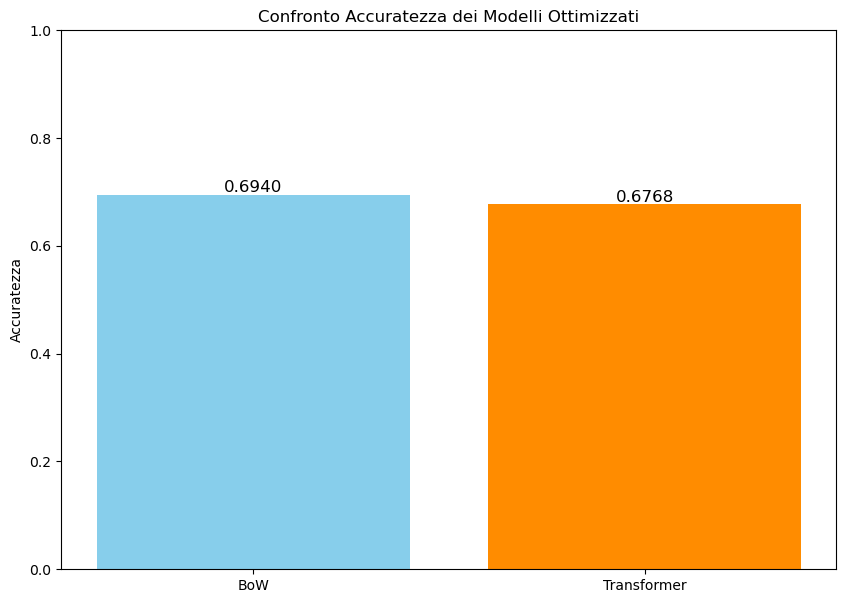

In [8]:
# Confronto Finale dei Risultati Ottimizzati

print("\n\n--- Riepilogo e Confronto delle Performance Ottimizzate ---")
print("="*60)
print(f"Accuratezza media (BoW):         {accuracy_bow:.4f}")
print(f"Accuratezza media (Transformer): {accuracy_transformer:.4f}")
print("="*60)



labels = ['BoW', 'Transformer']
accuracies = [accuracy_bow, accuracy_transformer]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(labels, accuracies, color=['skyblue', 'darkorange'])
ax.set_ylabel('Accuratezza')
ax.set_title('Confronto Accuratezza dei Modelli Ottimizzati')
ax.set_ylim(0, 1.0)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.4f}', va='bottom', ha='center', fontsize=12)

plt.show()